In [1]:
#cell 1 : Markdown
from IPython.display import Markdown
Markdown(r'''
# EE200:- ENDSEM PROJECT 
# Frequency-Demixer-Audio-DSP
         
---
''')


# EE200:- ENDSEM PROJECT 
# Frequency-Demixer-Audio-DSP

---


# Frequency de-mixer: ‘Unwanted Solo’
### NAME: SAMAY RAJ MEENA 
### ROLL NO: 240919
### Date: 30 June 2025

## 1. loading and noramlising of audio file

In [233]:
import librosa
import librosa.display
from scipy import signal
from scipy.signal import iirnotch, filtfilt, freqz, welch
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

#load the audio file
original_song = 'song_with_2piccolo.wav'
y, sr = librosa.load(original_song, sr=None) # sr stands for sampling rate

# 3. Normalize audio
y_normalized = y / np.max(np.abs(y))

#2. Print sampling rate and duration
print(f"Sample Rate: {sr} Hz")
print(f"Duration: {len(y) / sr:.2f} seconds")

Sample Rate: 48000 Hz
Duration: 15.00 seconds


## 2. display the waveform and spectrogram

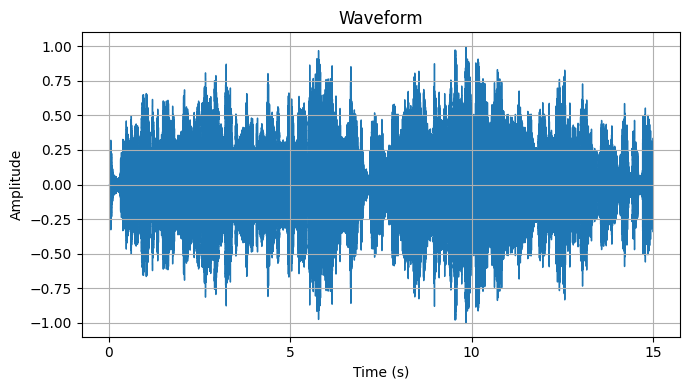

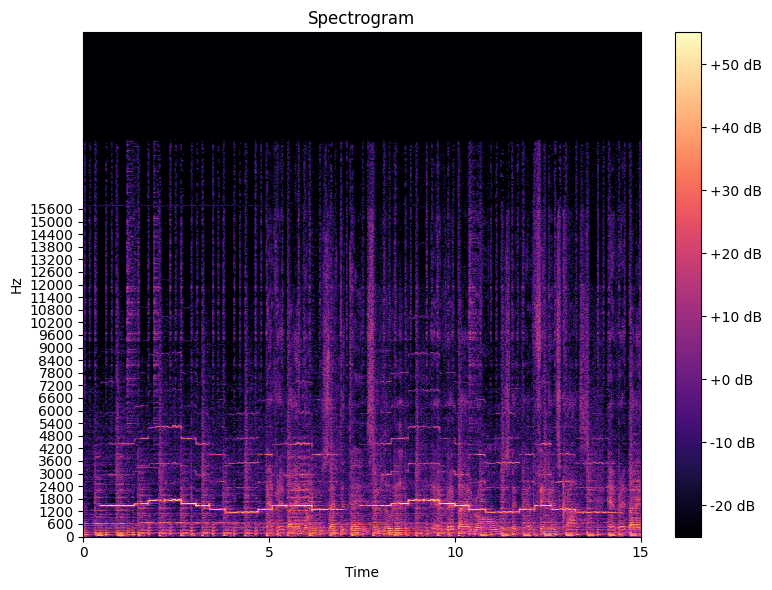

In [234]:
# 4. Plot the waveform
plt.figure(figsize=(7, 4))
librosa.display.waveshow(y_normalized, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Plot the spectrogram (in dB)
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# Use larger n_fft for better frequency resolution
n_fft = 4096  # Try 2048 or 4096
hop_length = 512

D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
S_db = librosa.amplitude_to_db(abs(D))

plt.figure(figsize=(8,6))
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')

# Manually set Y-axis ticks
plt.yticks(np.arange(0, sr//3, 600))  # 0 Hz to Nyquist, every 600 Hz
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.tight_layout()
plt.show()

## 3. display the frequency spectrum

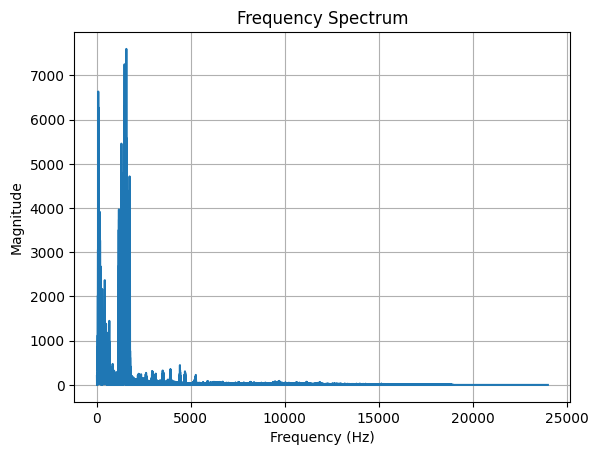

In [235]:
#plot the frequency spectrum
Y = np.fft.fft(y)
freqs = np.fft.fftfreq(len(Y), d=1/sr)

plt.plot(freqs[:len(freqs)//2], np.abs(Y[:len(Y)//2]))
plt.title("Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()


## 4. plotting of power spectral density(PSD)

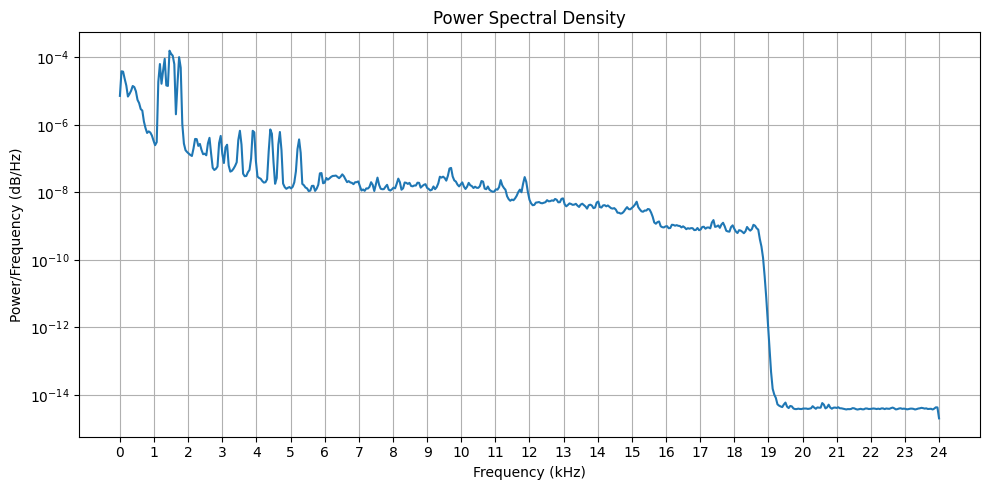

In [236]:
# step 5: Calculate Power Spectral Density using Welch's method
frequencies, psd = welch(y, fs=sr, nperseg=1024)

# Convert frequency axis from Hz to kHz
frequencies_khz = frequencies / 1000

# Plot the PSD
plt.figure(figsize=(10, 5))
plt.semilogy(frequencies_khz, psd)  # semilog Y for better visibility
plt.title('Power Spectral Density')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.grid(True)

# Set more x-axis ticks (e.g., every 1000 Hz)
xticks = (np.arange(0, sr//2 + 1, 1000))/1000
plt.xticks(xticks)

plt.tight_layout()
plt.show()

## 5. designing of notch filter

 from power spectral density plot we can easily observe that the unwanted frequencies is present between 
 1.0khz to 5.5khz so we need to remove these frequencies

In [237]:
# Start with identity filter (no effect)
b_total = np.array([1.0])
a_total = np.array([1.0])

# Step 2: Define the frequencies you want to remove
unwanted_freqs = [1498, 3000, 3300, 3500, 3800, 4000, 4300, 4500, 4700, 5000, 5250, 5500]  # in Hz
Q = 4  # Quality factor (adjust sharpness of notch)

# Step 3: Apply a notch filter for each unwanted frequency
for item in unwanted_freqs:
 b, a = iirnotch(item ,Q=Q, fs=sr)
 y_filtered = filtfilt(b, a, y_filtered)
 b_total = np.convolve(b_total, b)
 a_total = np.convolve(a_total, a)# apply notch filter to signal

gain = 4
y_amplified = y_filtered*gain

# Compute frequency response
w, h = freqz(b_total, a_total, worN=8000, fs = sr)

## 6. display the bode plots 

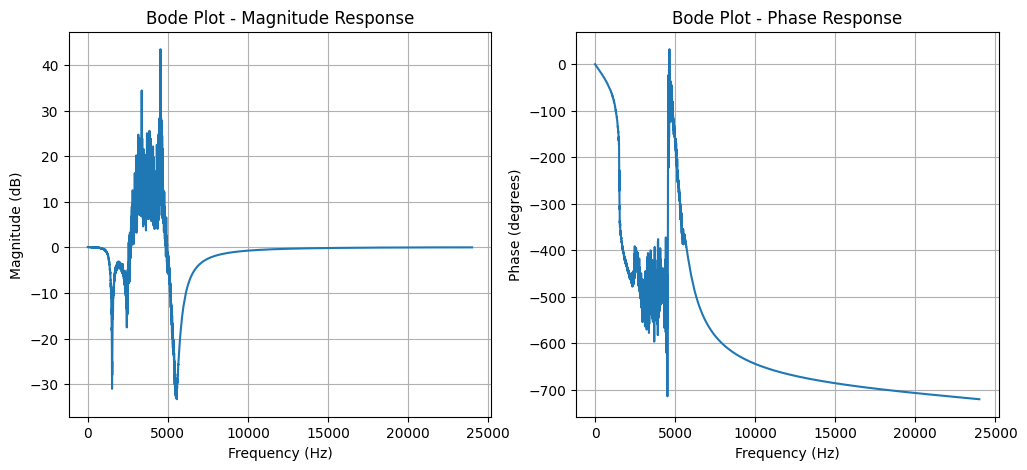

In [238]:
# step 4: Plot Bode plot
plt.figure(figsize=(12, 5))

# Magnitude
plt.subplot(1, 2, 1)
plt.plot(w, 20 * np.log10(abs(h)))
plt.title('Bode Plot - Magnitude Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid()

# Phase
plt.subplot(1, 2, 2)
angles = np.unwrap(np.angle(h))
plt.plot(w, np.degrees(angles))
plt.title('Bode Plot - Phase Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (degrees)')
plt.grid()

## 8. filtered audio as output

In [239]:
# STEP 7: Save the cleaned audio
sf.write("cleaned_audio.wav", y_amplified, sr)

***key observations*** :- now we have both filtered and original audio so we need to compare some important charactersitics to see the impact of notch filter. here we are comparing characteristics like power spectral density , waveform in time domain of original and filtered audio

## 9. comparision in PSD

([<matplotlib.axis.XTick at 0x20989328550>,
 [Text(0.0, 0, '0'),
  Text(1.0, 0, '1'),
  Text(2.0, 0, '2'),
  Text(3.0, 0, '3'),
  Text(4.0, 0, '4'),
  Text(5.0, 0, '5'),
  Text(6.0, 0, '6'),
  Text(7.0, 0, '7'),
  Text(8.0, 0, '8'),
  Text(9.0, 0, '9'),
  Text(10.0, 0, '10'),
  Text(11.0, 0, '11'),
  Text(12.0, 0, '12'),
  Text(13.0, 0, '13'),
  Text(14.0, 0, '14'),
  Text(15.0, 0, '15'),
  Text(16.0, 0, '16'),
  Text(17.0, 0, '17'),
  Text(18.0, 0, '18'),
  Text(19.0, 0, '19'),
  Text(20.0, 0, '20'),
  Text(21.0, 0, '21'),
  Text(22.0, 0, '22'),
  Text(23.0, 0, '23'),
  Text(24.0, 0, '24')])

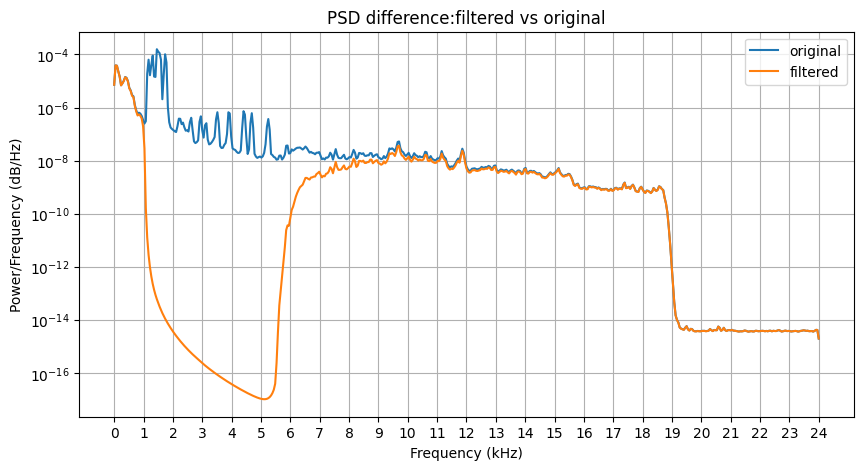

In [240]:
frequencies_new, psd_1 = welch(y_filtered, fs=sr, nperseg=1024)

frequencies_new_khz = frequencies_new / 1000 

plt.figure(figsize=(10, 5))
plt.semilogy(frequencies_khz, psd, label = 'original')
plt.semilogy(frequencies_khz, psd_1, label = 'filtered')  # semilog Y for better visibility
plt.title('PSD difference:filtered vs original')
plt.xlabel('Frequency (kHz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.legend()
plt.grid(True)

# Set more x-axis ticks (e.g., every 1000 Hz)
xticks = (np.arange(0, sr//2 + 1, 1000))/1000
plt.xticks(xticks)


# 10. comparision in waveform

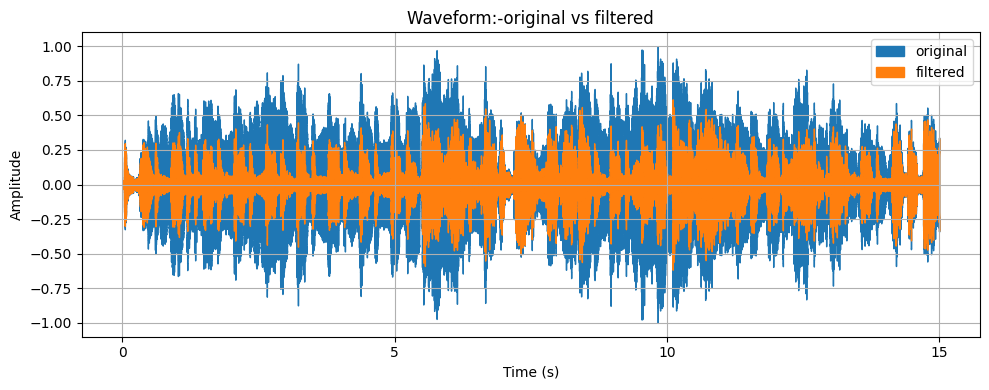

In [241]:
# 4. Plot the waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y_normalized, sr=sr, label = 'original')
librosa.display.waveshow(y_filtered, sr=sr, label = 'filtered')
plt.title("Waveform:-original vs filtered")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()